# Fuel Consumption Prediction — Exploratory Data Analysis

## Objective

This notebook explores the cleaned trip-level dataset used to predict vehicle fuel consumption.

The analysis focuses on:

- Target and trip distributions
- Fuel consumption vs. trip characteristics
- Engine and driving-behavior features
- Vehicle-level heterogeneity
- Feature correlations and redundancy
- Final modeling feature selection

**Target:** `trip_fuel_used_liter`

Each observation represents one cleaned and validated vehicle trip.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/trip_ml_features.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Vehicles: {df['vehicle_id'].nunique()}")
print(f"Periods: {df['period'].nunique()}")

df.head()

Rows: 9,923
Vehicles: 12
Periods: 3


,vehicle_id,trip_id,period,trip_start_time,trip_end_time,trip_distance_km,trip_duration_min,avg_speed_kmh,max_speed_kmh,speed_std,...,high_rpm_ratio,idle_ratio,trip_fuel_used_liter,fuel_match_diff_sec,fuel_match_confidence,trip_start_utc,trip_start_kst,trip_hour,day_of_week,is_weekend
0,VEH_01,VEH_01_AFTER_0001,After,2026-05-18 00:24:11.063000+00:00,2026-05-18 00:29:36+00:00,1.111030,5.415617,18.843750,64.0,18.330489,...,0.0,0.131770,0.23,1.827,High,2026-05-18 00:24:11.063000+00:00,2026-05-18 09:24:11.063000+09:00,9,0,0
1,VEH_01,VEH_01_AFTER_0002,After,2026-05-18 00:33:34.063000+00:00,2026-05-18 01:27:24+00:00,31.764637,53.832283,34.824490,97.0,29.338938,...,0.0,0.125489,2.97,1.243,High,2026-05-18 00:33:34.063000+00:00,2026-05-18 09:33:34.063000+09:00,9,0,0
2,VEH_01,VEH_01_AFTER_0003,After,2026-05-18 01:30:26.063000+00:00,2026-05-18 01:32:24+00:00,0.553123,1.965617,16.090909,45.0,11.992077,...,0.0,0.013247,0.07,23.913,High,2026-05-18 01:30:26.063000+00:00,2026-05-18 10:30:26.063000+09:00,10,0,0
3,VEH_01,VEH_01_AFTER_0004,After,2026-05-18 01:34:24.063000+00:00,2026-05-18 01:37:32+00:00,0.904879,3.132283,15.166667,39.0,13.062882,...,0.0,0.164649,0.11,1.397,High,2026-05-18 01:34:24.063000+00:00,2026-05-18 10:34:24.063000+09:00,10,0,0
4,VEH_01,VEH_01_AFTER_0005,After,2026-05-18 01:41:54.063000+00:00,2026-05-18 01:45:07+00:00,0.355524,3.215617,5.821429,19.0,6.324858,...,0.0,0.060621,0.07,4.290,High,2026-05-18 01:41:54.063000+00:00,2026-05-18 10:41:54.063000+09:00,10,0,0


## Target and Trip Characteristics

Trip fuel consumption, distance, and duration are right-skewed.

Trip distance is expected to be the dominant predictor because total fuel consumption naturally increases with trip exposure.

In [2]:
cols = [
    "trip_fuel_used_liter",
    "trip_distance_km",
    "trip_duration_min"
]

df[cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
trip_fuel_used_liter,9923.0,2.433906,5.294935,0.010000,0.020000,0.030000,0.340000,15.740000,22.366800,66.410000
trip_distance_km,9923.0,10.889835,19.941007,0.100000,0.104205,0.147363,1.951469,62.604850,86.747422,132.074070
trip_duration_min,9923.0,16.686879,20.173845,0.233333,0.650000,1.182283,8.365617,58.496562,93.865091,148.096667


In [3]:
print(
    "Fuel vs Distance:",
    df["trip_fuel_used_liter"].corr(df["trip_distance_km"])
)

print(
    "Fuel vs Duration:",
    df["trip_fuel_used_liter"].corr(df["trip_duration_min"])
)

Fuel vs Distance: 0.9184540061786443
Fuel vs Duration: 0.8317371951054127


In [4]:
behavior_features = [
    "avg_speed_kmh",
    "max_speed_kmh",
    "speed_std",
    "avg_rpm",
    "max_rpm",
    "rpm_std",
    "high_rpm_ratio",
    "idle_ratio"
]

behavior_corr = (
    df[behavior_features + ["trip_fuel_used_liter"]]
    .corr()["trip_fuel_used_liter"]
    .drop("trip_fuel_used_liter")
    .sort_values(ascending=False)
)

behavior_corr

avg_speed_kmh     0.707940
speed_std         0.608376
max_speed_kmh     0.537593
high_rpm_ratio   -0.042075
avg_rpm          -0.153512
max_rpm          -0.222267
rpm_std          -0.225408
idle_ratio       -0.261506
Name: trip_fuel_used_liter, dtype: float64

### Finding

Several speed variables show substantial raw correlation with fuel consumption.

However, previous distance-controlled analysis showed that these relationships become much weaker after controlling for trip distance and vehicle identity.

Therefore, driving-behavior variables are treated as incremental predictors rather than primary drivers of total fuel consumption.

In [5]:
vehicle_summary = (
    df.groupby("vehicle_id")
    .agg(
        trips=("trip_id", "count"),
        mean_fuel=("trip_fuel_used_liter", "mean"),
        mean_distance=("trip_distance_km", "mean"),
        mean_speed=("avg_speed_kmh", "mean"),
        mean_rpm=("avg_rpm", "mean"),
        mean_idle_ratio=("idle_ratio", "mean")
    )
    .round(3)
)

vehicle_summary

,trips,mean_fuel,mean_distance,mean_speed,mean_rpm,mean_idle_ratio
vehicle_id,,,,,,
VEH_01,1684,0.326,2.452,13.224,1132.358,0.150
VEH_02,637,0.734,5.308,20.880,1297.506,0.158
VEH_03,570,1.142,10.126,21.526,1211.682,0.144
VEH_04,687,1.036,8.267,20.048,1285.866,0.202
VEH_05,378,11.663,38.650,33.523,1000.450,0.092
VEH_06,583,9.572,34.682,36.955,1040.424,0.100
VEH_07,513,0.870,5.603,22.431,1293.858,0.187
VEH_08,757,0.653,6.602,18.273,1204.438,0.172
VEH_09,1829,0.301,1.985,15.636,1156.975,0.142


### Finding

Large differences exist across vehicles.

Several vehicles operate predominantly short trips, while others have much longer typical operating cycles.

Vehicle identity is therefore an important source of heterogeneity and will be evaluated separately in a vehicle-aware modeling experiment.

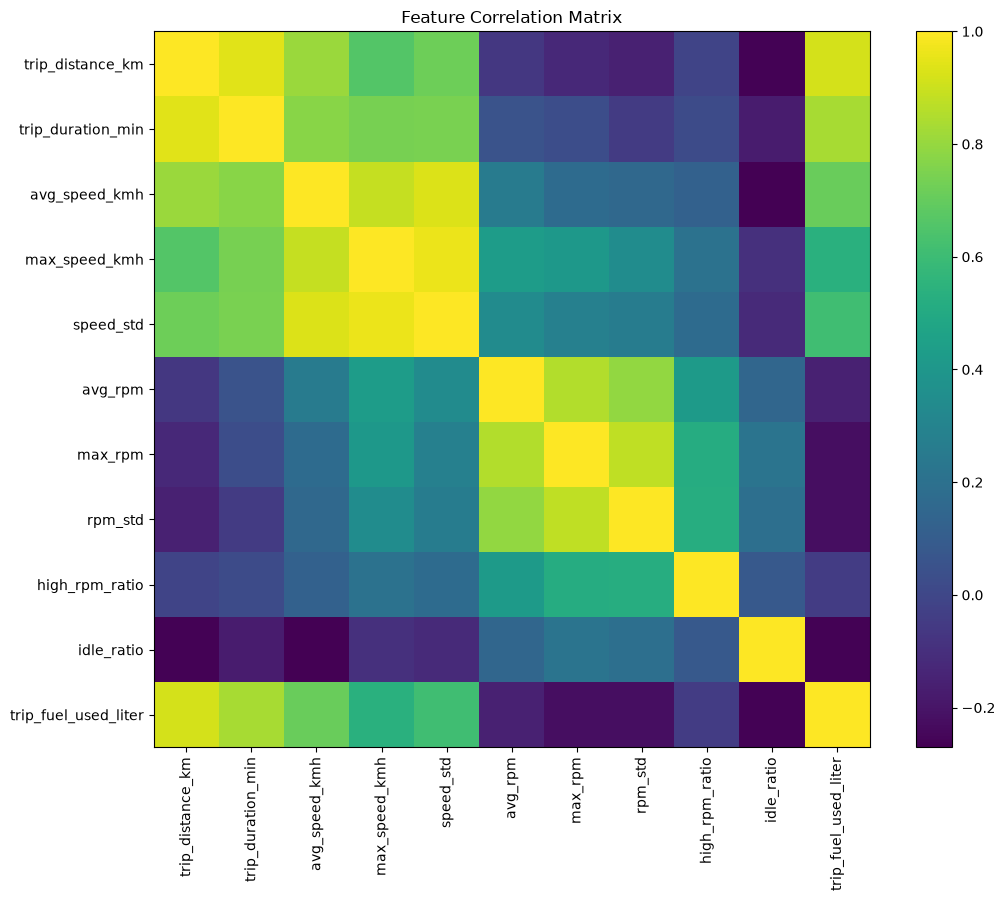

In [7]:
features = [
    "trip_distance_km",
    "trip_duration_min",
    "avg_speed_kmh",
    "max_speed_kmh",
    "speed_std",
    "avg_rpm",
    "max_rpm",
    "rpm_std",
    "high_rpm_ratio",
    "idle_ratio",
    "trip_fuel_used_liter"
]

corr = df[features].corr()

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(corr)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)
ax.set_yticklabels(features)

fig.colorbar(im)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Multicollinearity Findings

Strong redundancy exists among:

- Distance and Duration
- Average Speed, Maximum Speed, and Speed variability
- Average RPM, Maximum RPM, and RPM variability

These variables are retained initially because their incremental predictive value will be tested out-of-sample rather than determined solely from pairwise correlations.

## Final Modeling Feature Sets

### Baseline

- `trip_distance_km`
- `trip_duration_min`

### Extended

Baseline plus:

- `avg_speed_kmh`
- `max_speed_kmh`
- `speed_std`
- `avg_rpm`
- `max_rpm`
- `rpm_std`
- `high_rpm_ratio`
- `idle_ratio`

### Context Experiment

Extended plus:

- `trip_hour`
- `day_of_week`
- `is_weekend`

### Vehicle-Aware Experiment

Vehicle identity will be evaluated separately using `vehicle_id`.

`period` and `trip_id` are retained as metadata and are not included in the primary predictor matrix.

## Leakage Control

The target and all target-derived fuel variables are excluded from X.

## Final Decision

**GO — The dataset is ready for train / validation / test splitting and model development.**